# Computer Vision Project 1: Image Filtering and Hybrid Images

All projects in this course will be executed within an iPython notebook. Using an IPython notebooks is a convenient way for you to quickly and easily interact with the code. A notebook contains many blocks of code, each of which can be run independently. You can run a cell with ctrl+enter or shift+enter (to move to the next cell).


## Part 1: NumPy
### Setup
Before we get started, we'll do a quick check to ensure you've previously installed the `proj1_code` module by running the command `pip install -e .` in your terminal:

In [2]:
import sys
import subprocess

# 1. 查出当前 Notebook 到底在用哪个 Python 运行
current_python = sys.executable
print(f"当前 Notebook 真实使用的 Python 路径是：{current_python}")

# 2. 强行调用这个真实的 Python 去安装需要的包
print("正在强行安装 torch 和 torchvision，请耐心等待...")
subprocess.check_call([current_python, '-m', 'pip', 'install', 'torch', 'torchvision'])
print("安装完成！现在你可以尝试运行下面的代码了。")

当前 Notebook 真实使用的 Python 路径是：E:\app\anaconda\python.exe
正在强行安装 torch 和 torchvision，请耐心等待...
安装完成！现在你可以尝试运行下面的代码了。


In [3]:
import sys
sys.path.append('..')  # 强行将上一级目录加入 Python 的搜索路径

from proj1_code.utils import load_image, save_image
print("恭喜！成功导入模块！")

恭喜！成功导入模块！


If that didn't throw an error, then you're good to proceed!

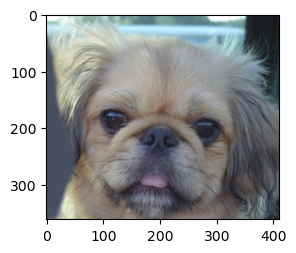

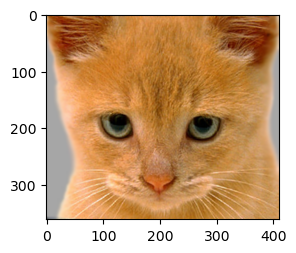

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from proj1_code.utils import load_image, save_image

%matplotlib inline
%load_ext autoreload
%autoreload 2


image1 = load_image('../data/1a_dog.bmp')
image2 = load_image('../data/1b_cat.bmp')

# display the dog and cat images
plt.figure(figsize=(3,3)); plt.imshow((image1*255).astype(np.uint8));
plt.figure(figsize=(3,3)); plt.imshow((image2*255).astype(np.uint8));

### Create filter

You will first need to implement `create_Gaussian_kernel_1D()`  in `part1.py`.

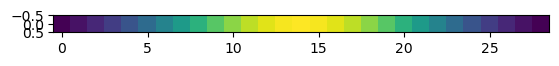

In [5]:
from proj1_code.part1 import create_Gaussian_kernel_1D
ksize = 29
sigma = 7
kernel_1d = create_Gaussian_kernel_1D(ksize, sigma)
plt.imshow(kernel_1d.T) # plot (N,1) column vector as (1,N) row vector 

You can run these two simple test cases to check if the implementation seems correct:

In [6]:
from proj1_code.utils import verify
from proj1_unit_tests.test_part1 import (
    test_create_Gaussian_kernel_1D,
    test_create_Gaussian_kernel_1D_sumsto1,
    test_create_Gaussian_kernel_1D_peak
)

print(verify(test_create_Gaussian_kernel_1D))
print(verify(test_create_Gaussian_kernel_1D_sumsto1))
print(verify(test_create_Gaussian_kernel_1D_peak))

"Correct"
"Correct"
"Correct"


Next, you will need to implement `create_Gaussian_kernel_2D()` (which can use `create_Gaussian_kernel_1D`)  in `part1.py`.

"Correct"
"Correct"
"Correct"
"Correct"
"Correct"


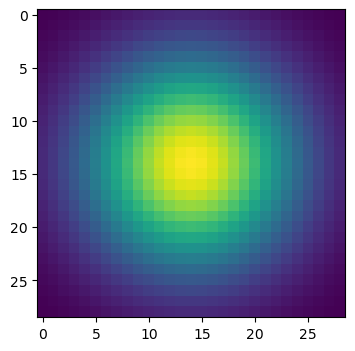

In [7]:
from proj1_code.part1 import create_Gaussian_kernel_2D
from proj1_code.utils import verify, PIL_resize
from proj1_unit_tests.test_part1 import (
    test_create_Gaussian_kernel_2D_sumsto1,
    test_create_Gaussian_kernel_2D_peak,
    test_gaussian_kernel_2D
)

cutoff_frequency = 7
kernel = create_Gaussian_kernel_2D(cutoff_frequency)

# let's take a look at the filter!
plt.figure(figsize=(4,4)); plt.imshow(kernel);

## Verify that the Gaussian kernel was created correctly
print(verify(test_create_Gaussian_kernel_1D_sumsto1))
print(verify(test_create_Gaussian_kernel_1D_peak))
print(verify(test_create_Gaussian_kernel_2D_sumsto1))
print(verify(test_create_Gaussian_kernel_2D_peak))
print(verify(test_gaussian_kernel_2D))
plt.savefig('../results/part1/gaussian_kernel.png', dpi=300, bbox_inches='tight')

### Apply filter to image
The next two functions you need to implement in this project can also be found in `part1.py`. Start by implementing `my_conv2d_numpy`, which takes both a filter and an image, and returns the filtered image. This code block will use your `my_conv2d_numpy` function to create and display a blurry version of image1.

"Correct"
"Correct"
"Correct"


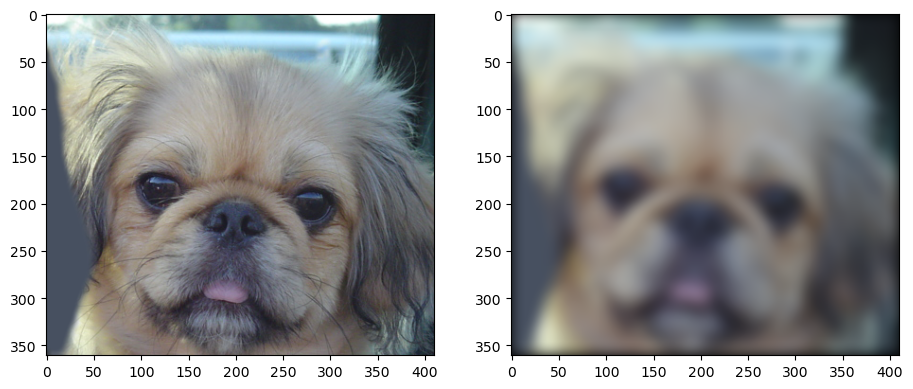

In [8]:
from proj1_code.part1 import (
    my_conv2d_numpy,
    create_hybrid_image
)
from proj1_unit_tests.test_part1 import (
    test_my_conv2d_numpy_identity,
    test_my_conv2d_numpy_ones_filter,
    test_my_conv2d_numpy_nonsquare_filter
)

blurry_image = my_conv2d_numpy(image1, kernel)

plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(image1)
plt.subplot(1,2,2); plt.imshow((blurry_image*255).astype(np.uint8))

## Verify that my_conv2d_numpy() was implemented correctly
print(verify(test_my_conv2d_numpy_identity))
print(verify(test_my_conv2d_numpy_ones_filter))
print(verify(test_my_conv2d_numpy_nonsquare_filter))

## Test Filtering

Here are a few test cases to help you test `my_conv2d_numpy()`, which you will write. You should verify that you get reasonable output here before using your filtering to construct a hybrid image in `part1.py`. The outputs are all saved and you can include them in your writeup.

In [9]:
test_image = load_image('../data/1b_cat.bmp')
original_height = test_image.shape[0]
original_width = test_image.shape[1]
test_image = PIL_resize(test_image, (int(0.7*original_width), int(0.7*original_height)))

### Identity filter
For the identity filter, the filtering result should look identical to the input.

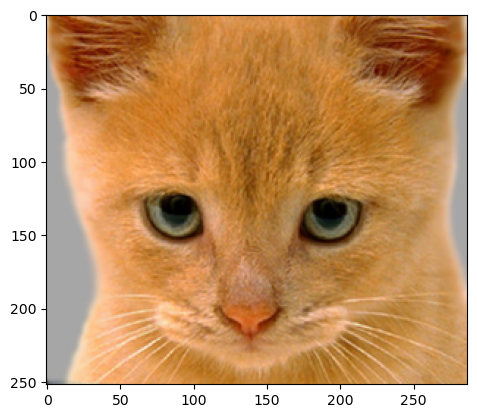

In [10]:
identity_filter = np.asarray([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
identity_image = my_conv2d_numpy(test_image, identity_filter)
plt.imshow(identity_image)
done = save_image('../results/part1/identity_image.jpg', identity_image)

### Small blur with a box filter
This filter should remove some high frequencies. (See the effect on the cat's whiskers, for example.)

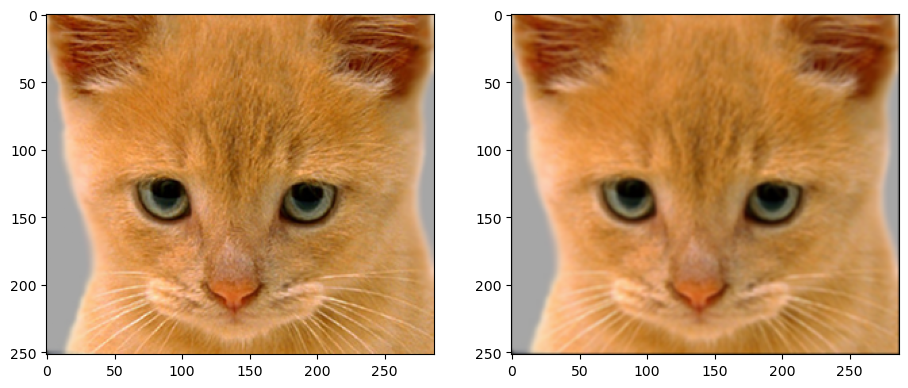

In [11]:
blur_filter = np.ones((3,3)) 
blur_filter /= np.sum(blur_filter)  # making the filter sum to 1
blur_image = my_conv2d_numpy(test_image, blur_filter)
plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(test_image)
plt.subplot(1,2,2); plt.imshow(blur_image)
done = save_image('../results/part1/blur_image.jpg', blur_image)

### Optimized my_conv2d_numpy()
Previous implementation of `my_conv2d_numpy()` remains a significant issue: the filtered image exhibit black borders around the edges, which become increasingly noticeable as the kernel size grows. Lets try to mitigate this issue.

Hint: You may consider the implementation of padding process. We encourage discussing various implementations in the report.

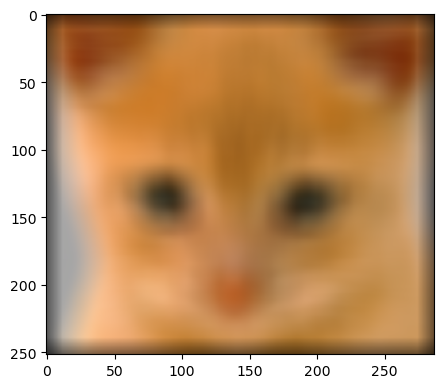

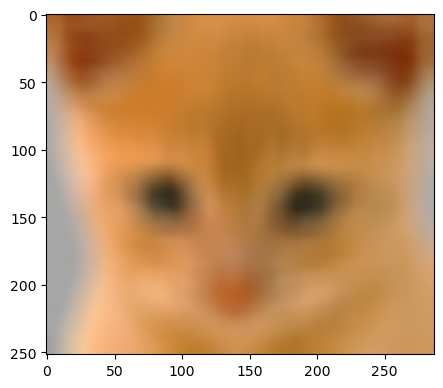

In [12]:
large_blur_filter = np.ones((25, 25))
large_blur_filter /= np.sum(large_blur_filter)
large_blur_image = my_conv2d_numpy(test_image, large_blur_filter)
plt.figure(figsize=(11,6)); plt.subplot(1,2,1); plt.imshow(large_blur_image); plt.show()    # you may see obvious black borders around the image edge
done = save_image("../results/part1/large_blur_image.jpg", large_blur_image)
# Here, you need to implement a v2 to optimize the issue mentioned above (1.4):
from proj1_code.part1 import (
    my_conv2d_numpy_v2,
)
large_blur_image = my_conv2d_numpy_v2(test_image, large_blur_filter)
plt.figure(figsize=(11,6)); plt.subplot(1,2,1); plt.imshow(large_blur_image); plt.show()
done = save_image("../results/part1/large_blur_image_v2.jpg", large_blur_image)

### Oriented filter (Sobel operator)

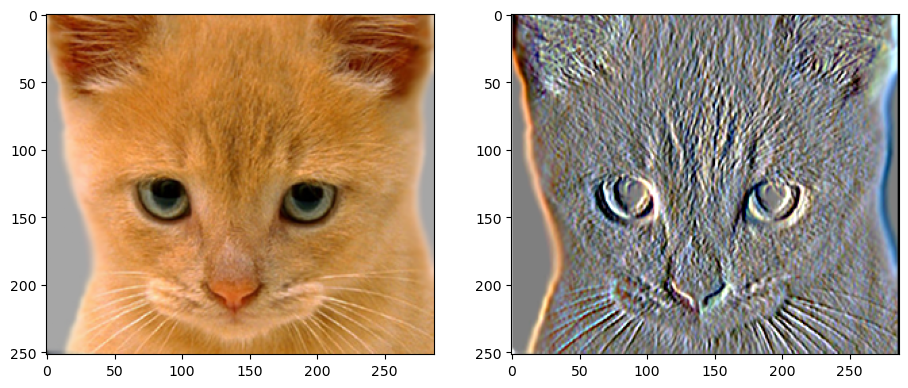

In [13]:
sobel_filter = np.asarray([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # should respond to horizontal gradients
sobel_image = my_conv2d_numpy(test_image, sobel_filter)

# 0.5 added because the output image is centered around zero otherwise and mostly black
sobel_image = np.clip(sobel_image+0.5, 0.0, 1.0)
plt.figure(figsize=(11,6))
plt.subplot(1,2,1); plt.imshow(test_image)
plt.subplot(1,2,2); plt.imshow(sobel_image)
done = save_image('../results/part1/sobel_image.jpg', sobel_image)

### High pass filter (discrete Laplacian)

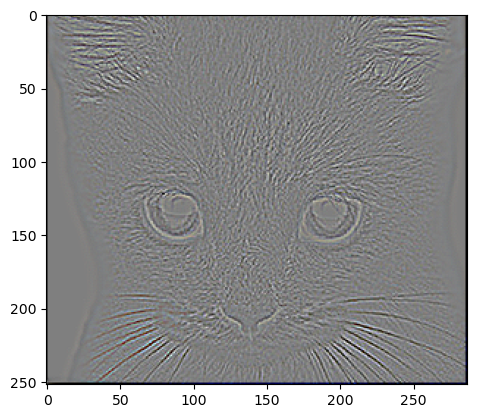

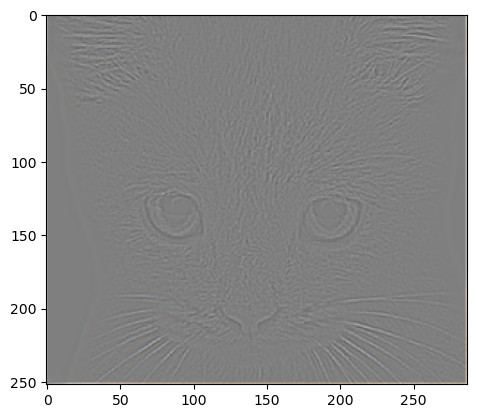

In [14]:
laplacian_filter = np.asarray([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
laplacian_image = my_conv2d_numpy(test_image, laplacian_filter)

# 0.5 is added because the output image is centered around zero otherwise and mostly black
laplacian_image = np.clip(laplacian_image+0.5, 0.0, 1.0)
plt.figure(); plt.imshow(laplacian_image)
done = save_image('../results/part1/laplacian_image.jpg', laplacian_image)

# High pass "filter" alternative
high_pass_image = test_image - blur_image
high_pass_image = np.clip(high_pass_image+0.5, 0.0, 1.0)
plt.figure(); plt.imshow(high_pass_image)
done = save_image('../results/part1/high_pass_image.jpg', high_pass_image)

## Create hybrid image
Next, implement `create_hybrid_image()`, which takes two images and makes a hybrid image using the low frequency content from one image and the high frequency content from another by applying the Gaussian kernel you defined in `create_Gaussian_kernel_2D()`.

Experiment with the value of `cutoff_frequency` for each pair of images in `data/`. For each image pair, replace `cutoff_frequencies.txt` with the best cutoff frequency value you find. The value on line *i* of the text file should correspond to _i_-th image pair. This is an important step for Part 2! Feel free to also experiment with which image in each pair you grab the low frequencies from and which image you grab high frequencies from.

In [ ]:
from proj1_code.utils import vis_image_scales_numpy
from proj1_unit_tests.test_part1 import test_hybrid_image_np

low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)

## Verify that results are as expected
print(verify(test_hybrid_image_np))

vis = vis_image_scales_numpy(hybrid_image)

### Show results

In [ ]:
plt.figure(figsize=(11,6));
plt.subplot(1,2,1); plt.imshow((low_frequencies*255).astype(np.uint8));
plt.subplot(1,2,2); plt.imshow(((high_frequencies+0.5)*255).astype(np.uint8));
plt.figure(figsize=(20, 20)); plt.imshow(vis);

### Save results

In [ ]:
save_image('../results/part1/low_frequencies.jpg', low_frequencies)
save_image('../results/part1/high_frequencies.jpg', high_frequencies+0.5)
save_image('../results/part1/hybrid_image.jpg', hybrid_image)
save_image('../results/part1/hybrid_image_scales.jpg', vis)

### Custom Hybrid Image
You are required to find at least one such pair of images from daily life or the internet to create your own custom hybrid image. In your report, please analyze what factors you believe contribute to the differences in the results produced by various image pairs.

In [ ]:
# 先安装依赖（只需要运行一次）
!pip install pillow
#用于将自定义图片格式调整一致
from PIL import Image

def process_and_convert(img_path, target_size, output_name):
    img = Image.open(img_path).convert("RGB")
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    new_img = Image.new("RGB", target_size, (255, 255, 255))
    paste_x = (target_size[0] - img.width) // 2
    paste_y = (target_size[1] - img.height) // 2
    new_img.paste(img, (paste_x, paste_y))
    new_img.save(output_name, format="BMP")
    print(f"已生成: {output_name}")

# 统一尺寸（可自己改，比如800x600）
TARGET_SIZE = (1000, 800)

# 处理两张图片
process_and_convert('../data/rhino.jpg', TARGET_SIZE, "rhino_aligned.bmp")
process_and_convert('../data/elephant.jpg', TARGET_SIZE, "elephant_aligned.bmp")

## Part 2: PyTorch 

Make sure you have specified a cutoff value in `cutoff_frequencies.txt` for each image pair in `data/` before executing the following blocks.

In [ ]:
import torch
import torchvision
import os

from proj1_code.part2_datasets import HybridImageDataset
from proj1_code.part2_models import HybridImageModel

if not os.path.exists('../results/part2/'):
        os.makedirs('../results/part2/')
        
data_root = '../data' # if you're using additional data, make sure to change this to '../additional_data'
cf_file = '../cutoff_frequencies.txt'

### Instantiate model & dataset
Implement `HybridImageModel` and `HybridImageDataset`, found in `part2_models.py` and `part2_datasets.py`, respectively.

In the code documentation, you will see a term called "batch size", which we will discuss in later projects and lectures. For now, we are using the default value of 1. 

In [ ]:
model = HybridImageModel()
dataset = HybridImageDataset(data_root, cf_file)
dataloader = torch.utils.data.DataLoader(dataset)

data_iter = iter(dataloader)

### Create hybrid images
This code block will iterate through pairs of images from your dataset and create a hybrid image using the low frequency content from one image and the high frequency content from another.

In [26]:
for i in range(len(dataset)):
    image_a, image_b, cutoff_frequency = next(data_iter)
    low_frequencies, high_frequencies, hybrid_image = model(image_a, image_b, cutoff_frequency)
    
    # saves low frequencies, high frequencies, and hybrid image of each pair of images
    torchvision.utils.save_image(low_frequencies, '../results/part2/%d_low_frequencies.jpg' % i)
    torchvision.utils.save_image(high_frequencies+0.5, '../results/part2/%d_high_frequencies.jpg' % i)
    torchvision.utils.save_image(hybrid_image, '../results/part2/%d_hybrid_image.jpg' % i)

StopIteration: 

In [15]:
## Verify that the results are correct
from proj1_unit_tests.test_part2 import (
    test_low_freq_sq_kernel_pytorch, 
    test_high_freq_sq_kernel_pytorch,
    test_hybrid_image_pytorch
)

## Verify that the Pytorch results are as expected
print(verify(test_low_freq_sq_kernel_pytorch))
print(verify(test_high_freq_sq_kernel_pytorch))
## Verify that the Pytorch hybrid images are created correctly
print(verify(test_hybrid_image_pytorch))

"Correct"
"Correct"
"Correct"


### Hybrid image timing comparison
Here, we will compare the runtime of creating hybrid images using your NumPy implementation to using your PyTorch implementation.

In [16]:
import time

image1 = load_image('../data/1a_dog.bmp')
image2 = load_image('../data/1b_cat.bmp')

Timing Part 1. Notice that we explicitly include `create_Gaussian_kernel()_2D` in the timing of Part 1 but not Part 2. This is because the function is already being called (and therefore timed) inside the forward pass of `HybridImageModel`.

In [17]:
start = time.time()
cutoff_frequency = 7
kernel = create_Gaussian_kernel_2D(cutoff_frequency)
low_frequencies, high_frequencies, hybrid_image = create_hybrid_image(image1, image2, kernel)
end = time.time() - start
print('Part 1: {:.3f} seconds'.format(end))

Part 1: 9.015 seconds


Timing Part 2

In [18]:
model = HybridImageModel()

start = time.time()
low_frequencies, high_frequencies, hybrid_image = model(image_a, image_b, torch.Tensor([cutoff_frequency]))
end = time.time() - start
print('Part 2: {:.3f} seconds'.format(end))

NameError: name 'HybridImageModel' is not defined

## Part 3: Understanding input/output shapes in PyTorch
Up until this point, we have produced a filtered output that has the same dimensions as the input image. Let's explore how you can stack multiple filters, apply them in a single operation using your `my_conv2d_pytorch` implementation in `part3.py`, and see how it affects the output shape.

In [ ]:
from proj1_unit_tests.test_part3 import test_my_conv2d_pytorch

# Verify that feature maps are correctly created
print(verify(test_my_conv2d_pytorch))

In [ ]:
image = load_image('../data/1a_dog.bmp')

# turn HW image into CHW, where C=1 for grayscale
image = np.transpose(image, (2,0,1))
print('Image has shape: ', image.shape)
image = torch.from_numpy(image).unsqueeze(0) #convert to tensor and add batch dimension

In [ ]:
from proj1_code.part3 import my_conv2d_pytorch

# stack all the test filters along the channel dimension
filter_bank = np.stack(
    [
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter],
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter],
        [identity_filter], 
        [blur_filter],
        [sobel_filter], 
        [laplacian_filter]
    ])
print('Filter bank has shape: ', filter_bank.shape)

filter_bank = torch.from_numpy(filter_bank).float()
# Run the image filtering operation
feature_maps = my_conv2d_pytorch(image, filter_bank)

Let's take a look at the output shape.

In [ ]:
print(feature_maps.shape)

Matplotlib requires numpy arrays with a particular shape format (h, w, c) for visualizing images. Here, we split and convert `feature_maps` to the appropriate shape arrays.

In [ ]:
for idx in range(4):  # we are stacking 4 filters in the filter bank
    print('Visualization {}:'.format(idx))
    feature_map = feature_maps[0, [idx, idx+4, idx+8], :, :]
    # (c, h, w) --> (h, w, c) for matplotlib visualization purposes
    feature_map = np.transpose(feature_map.numpy(),(1,2,0))
    plt.figure()
    offset = 0 #offset for vis purposes. sobel and laplace use .5
    if idx > 1:
        offset = .5
    plt.imshow(np.clip(feature_map+offset,0,1))
    plt.show()
    save_image('../results/part3/visualization_{}.jpg'.format(idx), feature_map)

### Part 4: Frequency Compression and Image Filtering
Refer to the requirements in Part 4 and implement the necessary code on your own.

In [ ]:
raise NotImplementedError(
    "You need to finish the code by yourself."
)